# Notebook 4 — Modelo k-Nearest Neighbors (kNN)

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = sorted(pc or paths, key=len)[0] if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())


Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann


In [2]:
from src.config import Config
from src.evaluation import get_confusion_matrix, compute_metrics
from src.visualization import plot_confusion_matrix
from sklearn.metrics import classification_report

features_dir = Config.PROCESSED_DIR / 'features'
data = np.load(features_dir / 'emg_features_base.npz', allow_pickle=True)
meta = np.load(features_dir / 'emg_metadata_base.npz', allow_pickle=True)

X      = data['X']
y      = data['y']
splits = meta['splits']

train_idx = np.where(splits == 'train_samples')[0]
test_idx  = np.where(splits == 'test_samples')[0]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

class_names = sorted(np.unique(y).tolist())
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Clases:', class_names)


Train: (12500, 48)  |  Test: (6250, 48)
Clases: ['fist', 'open', 'pinch', 'waveIn', 'waveOut']


In [3]:
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan'],
}

print('Iniciando Grid Search...')
grid_knn = GridSearchCV(pipeline_knn, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)
print('Mejores parámetros:', grid_knn.best_params_)


Iniciando Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.72128 0.71984 0.73032 0.73064 0.73712 0.73864 0.73784 0.73816     nan
 0.71984     nan 0.72968     nan 0.73648     nan 0.73864]
  warnings.warn(


Reporte kNN:

              precision    recall  f1-score   support

        fist       0.93      0.94      0.94      1250
        open       0.89      0.85      0.87      1250
       pinch       0.89      0.92      0.90      1250
      waveIn       0.92      0.92      0.92      1250
     waveOut       0.95      0.94      0.94      1250

    accuracy                           0.91      6250
   macro avg       0.91      0.91      0.91      6250
weighted avg       0.91      0.91      0.91      6250



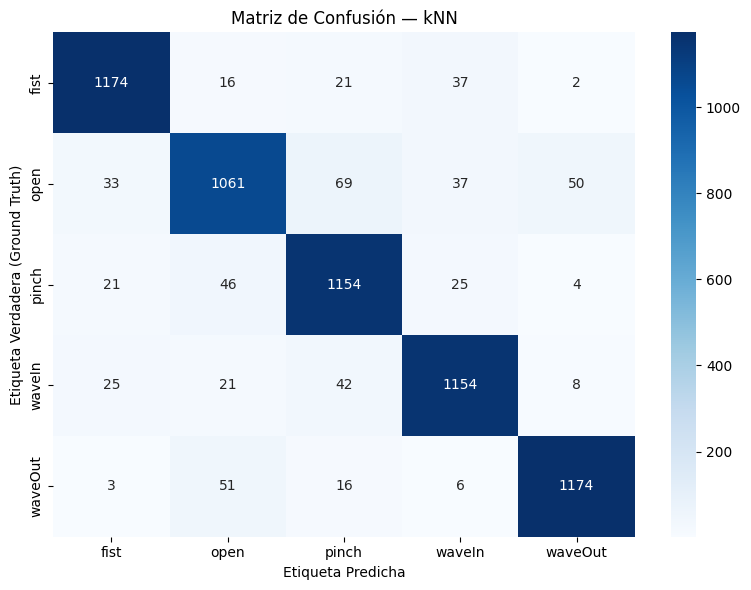

In [4]:
best_knn = grid_knn.best_estimator_
y_pred   = best_knn.predict(X_test)

print('Reporte kNN:\n')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = get_confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, class_names, title='Matriz de Confusión — kNN')


In [5]:
models_dir = Config.PROCESSED_DIR / 'models'
os.makedirs(models_dir, exist_ok=True)
joblib.dump(best_knn, models_dir / 'best_knn_model.pkl')
print('Modelo kNN guardado.')


Modelo kNN guardado.
